In [1]:
!pip install easyfsl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 78.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-10.

In [2]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import Omniglot
from torchvision.models import resnet18
from tqdm import tqdm

from easyfsl.samplers import TaskSampler
from easyfsl.utils import plot_images, sliding_average

In [3]:
image_size = 28

# NB: background=True selects the train set, background=False selects the test set
# It's the nomenclature from the original paper, we just have to deal with it

train_set = Omniglot(
    root="./data",
    background=True,
    transform=transforms.Compose(
        [
            transforms.Grayscale(num_output_channels=3),
            transforms.RandomResizedCrop(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
        ]
    ),
    download=True,
)
test_set = Omniglot(
    root="./data",
    background=False,
    transform=transforms.Compose(
        [
            # Omniglot images have 1 channel, but our model will expect 3-channel images
            transforms.Grayscale(num_output_channels=3),
            transforms.Resize([int(image_size * 1.15), int(image_size * 1.15)]),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
        ]
    ),
    download=True,
)

100%|██████████| 9.46M/9.46M [00:00<00:00, 93.2MB/s]
100%|██████████| 6.46M/6.46M [00:00<00:00, 77.5MB/s]


In [4]:
class PrototypicalNetworks(nn.Module):
    def __init__(self, backbone: nn.Module):
        super(PrototypicalNetworks, self).__init__()
        self.backbone = backbone

    def forward(
        self,
        support_images: torch.Tensor,
        support_labels: torch.Tensor,
        query_images: torch.Tensor,
    ) -> torch.Tensor:
        """
        Predict query labels using labeled support images.
        """
        # Extract the features of support and query images
        z_support = self.backbone.forward(support_images)
        z_query = self.backbone.forward(query_images)

        # Infer the number of different classes from the labels of the support set
        n_way = len(torch.unique(support_labels))
        # Prototype i is the mean of all instances of features corresponding to labels == i
        z_proto = torch.cat(
            [
                z_support[torch.nonzero(support_labels == label)].mean(0)
                for label in range(n_way)
            ]
        )

        # Compute the euclidean distance from queries to prototypes
        dists = torch.cdist(z_query, z_proto)

        # And here is the super complicated operation to transform those distances into classification scores!
        scores = -dists
        return scores


convolutional_network = resnet18(pretrained=True)
convolutional_network.fc = nn.Flatten()
print(convolutional_network)

model = PrototypicalNetworks(convolutional_network).cuda()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
N_WAY = 10 # Number of classes in a task
N_SHOT = 5 # Number of images per class in the support set
N_QUERY = 10 # Number of images per class in the query set
N_EVALUATION_TASKS = 100

# The sampler needs a dataset with a "get_labels" method. Check the code if you have any doubt!
test_set.get_labels = lambda: [instance[1] for instance in test_set._flat_character_images]
test_sampler = TaskSampler(
    test_set, n_way=N_WAY, n_shot=N_SHOT, n_query=N_QUERY, n_tasks=N_EVALUATION_TASKS
)

test_loader = DataLoader(
    test_set,
    batch_sampler=test_sampler,
    num_workers=12,
    pin_memory=True,
    collate_fn=test_sampler.episodic_collate_fn,
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


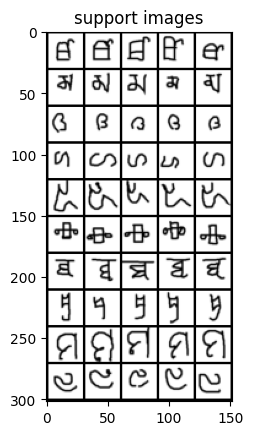

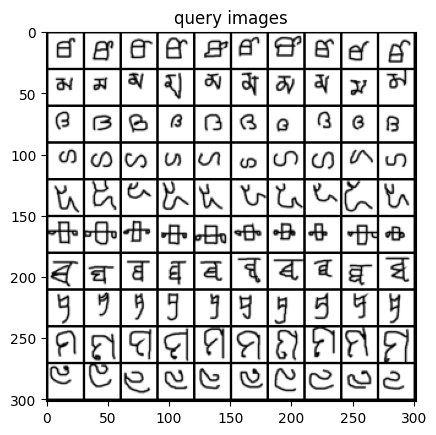

In [6]:
(
    example_support_images,
    example_support_labels,
    example_query_images,
    example_query_labels,
    example_class_ids,
) = next(iter(test_loader))

plot_images(example_support_images, "support images", images_per_row=N_SHOT)
plot_images(example_query_images, "query images", images_per_row=N_QUERY)


In [7]:
model.eval()
example_scores = model(
    example_support_images.cuda(),
    example_support_labels.cuda(),
    example_query_images.cuda(),
).detach()

_, example_predicted_labels = torch.max(example_scores.data, 1)

print("Ground Truth / Predicted")
for i in range(len(example_query_labels)):
    print(
        f"{test_set._characters[example_class_ids[example_query_labels[i]]]} / {test_set._characters[example_class_ids[example_predicted_labels[i]]]}"
    )

Ground Truth / Predicted
Manipuri/character35 / Manipuri/character35
Manipuri/character35 / Manipuri/character35
Manipuri/character35 / Malayalam/character20
Manipuri/character35 / Manipuri/character35
Manipuri/character35 / Sylheti/character04
Manipuri/character35 / Manipuri/character35
Manipuri/character35 / Manipuri/character35
Manipuri/character35 / Manipuri/character35
Manipuri/character35 / Manipuri/character35
Manipuri/character35 / Manipuri/character35
Tibetan/character24 / Tibetan/character24
Tibetan/character24 / Tibetan/character24
Tibetan/character24 / Glagolitic/character24
Tibetan/character24 / Atemayar_Qelisayer/character26
Tibetan/character24 / Tibetan/character24
Tibetan/character24 / Tibetan/character24
Tibetan/character24 / Malayalam/character14
Tibetan/character24 / Tibetan/character24
Tibetan/character24 / Atemayar_Qelisayer/character26
Tibetan/character24 / Tibetan/character24
Malayalam/character14 / Malayalam/character14
Malayalam/character14 / Malayalam/characte

In [8]:
def evaluate_on_one_task(
    support_images: torch.Tensor,
    support_labels: torch.Tensor,
    query_images: torch.Tensor,
    query_labels: torch.Tensor,
) -> [int, int]:
    """
    Returns the number of correct predictions of query labels, and the total number of predictions.
    """
    return (
        torch.max(
            model(support_images.cuda(), support_labels.cuda(), query_images.cuda())
            .detach()
            .data,
            1,
        )[1]
        == query_labels.cuda()
    ).sum().item(), len(query_labels)


def evaluate(data_loader: DataLoader):
    # We'll count everything and compute the ratio at the end
    total_predictions = 0
    correct_predictions = 0

    # eval mode affects the behaviour of some layers (such as batch normalization or dropout)
    # no_grad() tells torch not to keep in memory the whole computational graph (it's more lightweight this way)
    model.eval()
    with torch.no_grad():
        for episode_index, (
            support_images,
            support_labels,
            query_images,
            query_labels,
            class_ids,
        ) in tqdm(enumerate(data_loader), total=len(data_loader)):

            correct, total = evaluate_on_one_task(
                support_images, support_labels, query_images, query_labels
            )

            total_predictions += total
            correct_predictions += correct

    print(
        f"Model tested on {len(data_loader)} tasks. Accuracy: {(100 * correct_predictions/total_predictions):.2f}%"
    )


evaluate(test_loader)

100%|██████████| 100/100 [00:04<00:00, 24.03it/s]

Model tested on 100 tasks. Accuracy: 77.80%


In [9]:
N_TRAINING_EPISODES = 40000
N_VALIDATION_TASKS = 100

# train_set.labels = [instance[1] for instance in train_set._flat_character_images]   #incorrect, ignore this line; the following line is correct. 
train_set.get_labels = lambda: [instance[1] for instance in train_set._flat_character_images]

train_sampler = TaskSampler(
    train_set, n_way=N_WAY, n_shot=N_SHOT, n_query=N_QUERY, n_tasks=N_TRAINING_EPISODES
)
train_loader = DataLoader(
    train_set,
    batch_sampler=train_sampler,
    num_workers=12,
    pin_memory=True,
    collate_fn=train_sampler.episodic_collate_fn,
)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


def fit(
    support_images: torch.Tensor,
    support_labels: torch.Tensor,
    query_images: torch.Tensor,
    query_labels: torch.Tensor,
) -> float:
    optimizer.zero_grad()
    classification_scores = model(
        support_images.cuda(), support_labels.cuda(), query_images.cuda()
    )

    loss = criterion(classification_scores, query_labels.cuda())
    loss.backward()
    optimizer.step()

    return loss.item()

In [11]:
# Train the model yourself with this cell

log_update_frequency = 10

all_loss = []
model.train()
with tqdm(enumerate(train_loader), total=len(train_loader)) as tqdm_train:
    for episode_index, (
        support_images,
        support_labels,
        query_images,
        query_labels,
        _,
    ) in tqdm_train:
        loss_value = fit(support_images, support_labels, query_images, query_labels)
        all_loss.append(loss_value)

        if episode_index % log_update_frequency == 0:
            tqdm_train.set_postfix(loss=sliding_average(all_loss, log_update_frequency))

100%|██████████| 40000/40000 [38:17<00:00, 17.41it/s, loss=0.38]


In [12]:
# Or just load mine

!wget https://public-sicara.s3.eu-central-1.amazonaws.com/easy-fsl/resnet18_with_pretraining.tar
model.load_state_dict(torch.load("resnet18_with_pretraining.tar", map_location="cuda"))

--2025-06-04 07:41:11--  https://public-sicara.s3.eu-central-1.amazonaws.com/easy-fsl/resnet18_with_pretraining.tar
Resolving public-sicara.s3.eu-central-1.amazonaws.com (public-sicara.s3.eu-central-1.amazonaws.com)... 52.219.140.24, 3.5.136.88, 52.219.169.250, ...
Connecting to public-sicara.s3.eu-central-1.amazonaws.com (public-sicara.s3.eu-central-1.amazonaws.com)|52.219.140.24|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 44787039 (43M) [application/x-tar]
Saving to: ‘resnet18_with_pretraining.tar’

resnet18_with_pretr 100%[===================>]  42.71M  18.2MB/s    in 2.3s    

2025-06-04 07:41:14 (18.2 MB/s) - ‘resnet18_with_pretraining.tar’ saved [44787039/44787039]



<All keys matched successfully>

In [13]:
evaluate(test_loader)

100%|██████████| 100/100 [00:03<00:00, 25.68it/s]

Model tested on 100 tasks. Accuracy: 96.29%


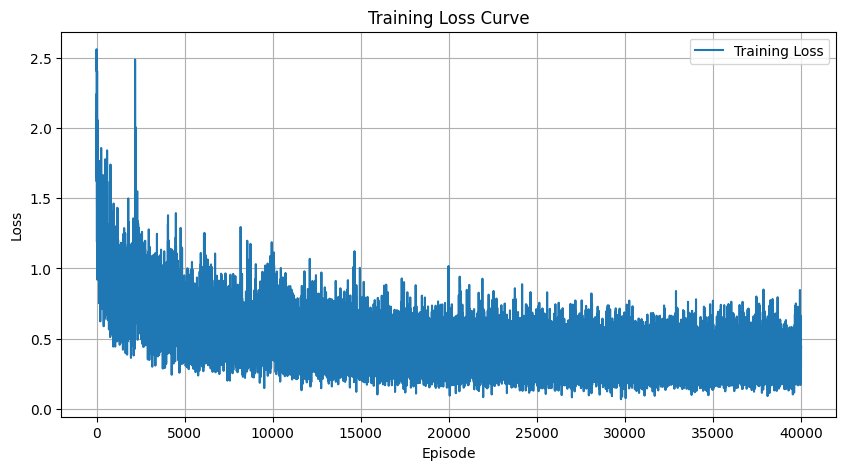

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(all_loss, label="Training Loss")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

Length of smooth_loss: 39901
Length of episodes: 39901


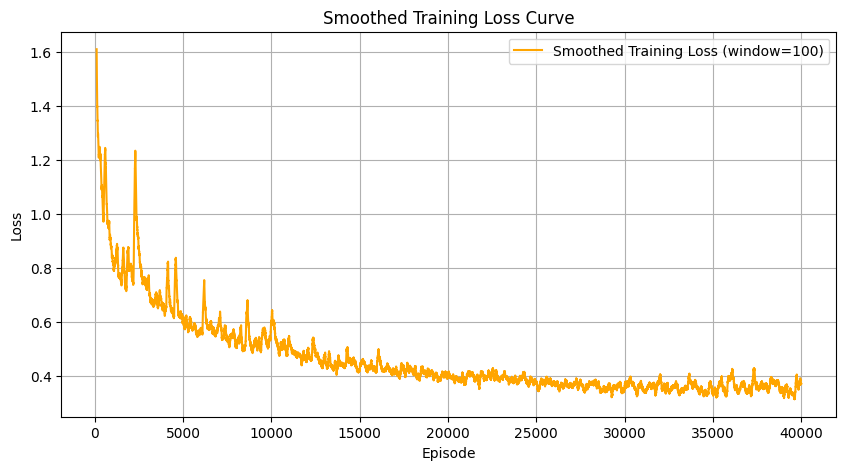

In [15]:
import matplotlib.pyplot as plt

# Helper function: average over a sliding window
def sliding_average(values, window):
    if len(values) < window:
        return []
    return [sum(values[i:i+window]) / window for i in range(len(values) - window + 1)]

window_size = 100

# Safety check
if len(all_loss) >= window_size:
    smooth_loss = sliding_average(all_loss, window_size)
    episodes = list(range(window_size - 1, len(all_loss)))

    print(f"Length of smooth_loss: {len(smooth_loss)}")
    print(f"Length of episodes: {len(episodes)}")

    plt.figure(figsize=(10, 5))
    plt.plot(episodes, smooth_loss, label=f"Smoothed Training Loss (window={window_size})", color="orange")
    plt.xlabel("Episode")
    plt.ylabel("Loss")
    plt.title("Smoothed Training Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print(f"Not enough data to plot smoothed loss (need at least {window_size} episodes).")


In [16]:
print(f"Length of all_loss: {len(all_loss)}")
print("First few loss values:", all_loss[:5])

Length of all_loss: 40000
First few loss values: [2.408759117126465, 1.9895329475402832, 2.072857141494751, 2.5610151290893555, 2.080693006515503]


In [17]:
# Get one few-shot task
(
    support_images,
    support_labels,
    query_images,
    query_labels,
    class_ids,
) = next(iter(test_loader))

# Run model on query images
model.eval()
scores = model(support_images.cuda(), support_labels.cuda(), query_images.cuda()).detach()
_, predicted_labels = torch.max(scores.data, 1)

print("\nGround Truth / Predicted Character Names:\n")
for i in range(len(query_labels)):


    
    true_class_idx = class_ids[query_labels[i]]
    pred_class_idx = class_ids[predicted_labels[i]]

    true_char = test_set._characters[true_class_idx]
    pred_char = test_set._characters[pred_class_idx]

    print(f"{true_char} / {pred_char}")


Ground Truth / Predicted Character Names:

Angelic/character20 / Angelic/character20
Angelic/character20 / Angelic/character20
Angelic/character20 / Angelic/character20
Angelic/character20 / Angelic/character20
Angelic/character20 / Angelic/character20
Angelic/character20 / Angelic/character20
Angelic/character20 / Angelic/character20
Angelic/character20 / Angelic/character20
Angelic/character20 / Angelic/character20
Angelic/character20 / Angelic/character20
Gurmukhi/character23 / Gurmukhi/character23
Gurmukhi/character23 / Gurmukhi/character23
Gurmukhi/character23 / Gurmukhi/character23
Gurmukhi/character23 / Gurmukhi/character23
Gurmukhi/character23 / Gurmukhi/character11
Gurmukhi/character23 / Gurmukhi/character23
Gurmukhi/character23 / Gurmukhi/character23
Gurmukhi/character23 / Gurmukhi/character23
Gurmukhi/character23 / Gurmukhi/character11
Gurmukhi/character23 / Gurmukhi/character23
Kannada/character39 / Kannada/character39
Kannada/character39 / Kannada/character39
Kannada/char

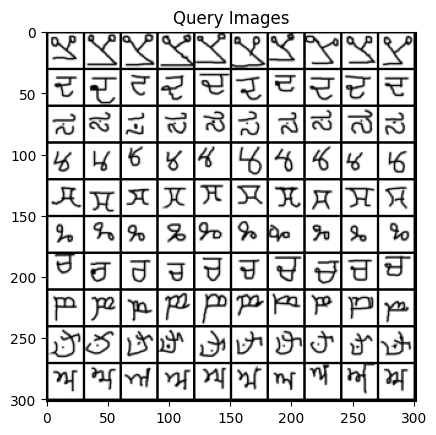

In [18]:
from easyfsl.utils import plot_images

plot_images(query_images, "Query Images", images_per_row=N_QUERY)
